In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# ---------------------------------------------------------------------
# 1) Load & label
# ---------------------------------------------------------------------
hammer = (
    pd.read_csv("hammer3.csv")
      .rename(columns={'p_flip_manual': 'p_flip'})   # align column names
      .assign(condition='hammer')
)

baseline = (
    pd.read_csv("baseline.csv")                      # put your filename here
      .assign(condition='baseline')
)

# long form: one row = one qubit observation
df_long = pd.concat([hammer, baseline], ignore_index=True)

# wide form: one row = hammer & baseline side-by-side → compute deltas
df_wide = (
    hammer.merge(
        baseline,
        on=['backend', 'INIT_STATE', 'center_q'],
        suffixes=('_hammer', '_baseline')
    )
)
df_wide['percent_change'] = (
    (df_wide['p_flip_hammer'] - df_wide['p_flip_baseline'])
    / df_wide['p_flip_baseline']
) * 100         # ‰ if you prefer per-cent or per-mille

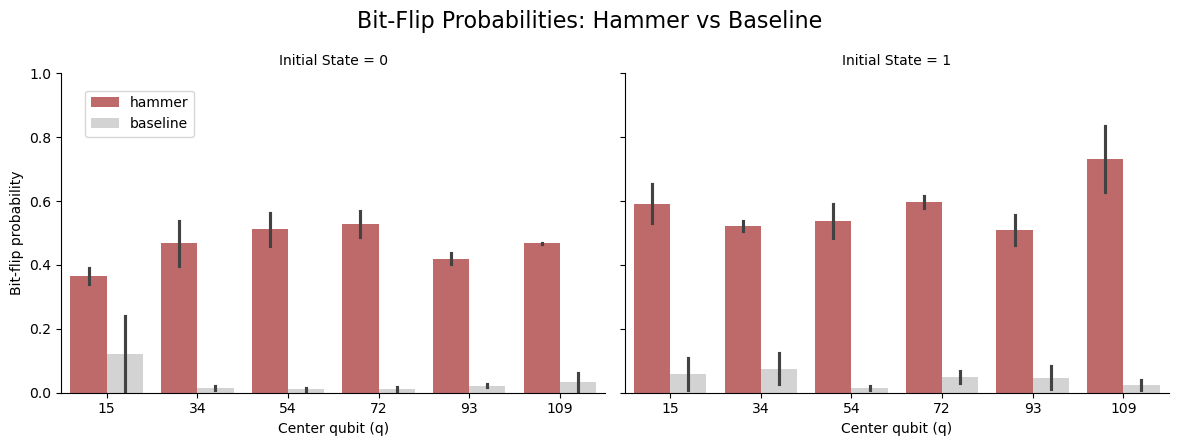

In [4]:
# ---------------------------------------------------------------------
# 2a) Raw probabilities (baseline vs hammer side-by-side)
# ---------------------------------------------------------------------
palette = {
    'baseline': 'lightgray',
    'hammer'  : 'indianred'
}

g = sns.catplot(
    data=df_long,
    x='center_q',
    y='p_flip',
    hue='condition',
    col='INIT_STATE',
    kind='bar',
    palette=palette,
    height=4.5, aspect=1.2, dodge=True
)

g.fig.suptitle("Bit-Flip Probabilities: Hammer vs Baseline", fontsize=16)

for ax in g.axes.flat:
    ax.set_ylim(0, 1)
g.set_axis_labels("Center qubit (q)", "Bit-flip probability")
g.set_titles("Initial State = {col_name}")
g.figure.tight_layout()
g._legend.set_title("")          # shorter legend title
g._legend.remove()
# Use plt.legend() to place it manually
plt.legend(
    loc="lower right",
    bbox_to_anchor=(-0.78, 0.78)
)
plt.savefig('plots/hammer_vs_baseline.png')
plt.show()


In [8]:
# ---------------------------------------------------------------------
# 1) Load & label
# ---------------------------------------------------------------------
df = pd.read_csv("hammer_H.csv")

In [ ]:
can i set the x-ticks to be : 15, 34, 54, 72, 93, 109

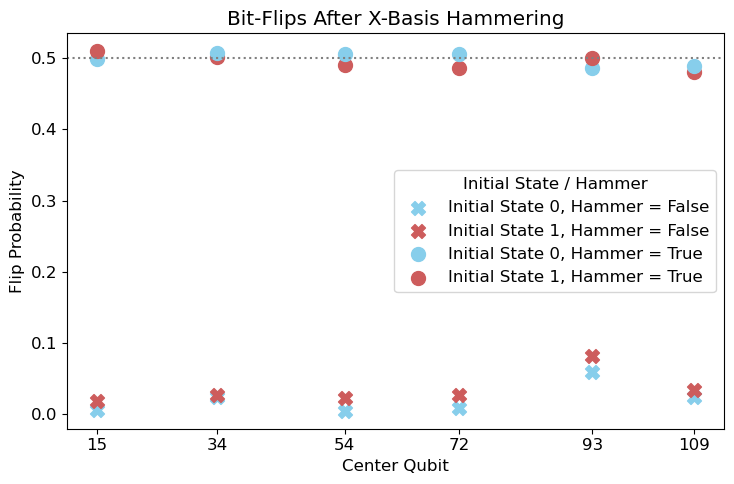

In [60]:
df = pd.read_csv("hammer_H.csv")
df = df[df['gate']=='cx']
df["hammer"] = df["hammer"].astype(bool)

# Plot with color = INIT_STATE, marker = hammer
plt.figure(figsize=(7.5, 5))
plt.rcParams.update({'font.size': 12})
palette = {0: "skyblue", 1: "indianred"}  # Blue for INIT 0, Orange for INIT 1
markers = {False: "X", True: "o"}

for _, row in df.iterrows():
    plt.scatter(
        row["CENTER_Q"], row["p_flip"],
        color=palette[row["INIT_STATE"]],
        marker=markers[row["hammer"]],
        s=100,
        label=f"Initial State {row['INIT_STATE']}, Hammer = {row['hammer']}"
    )

# Avoid duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), title="Initial State / Hammer")

plt.axhline(0.5, ls=":", c="gray")
plt.xticks([15, 34, 54, 72, 93, 109])
plt.xlabel("Center Qubit")
plt.ylabel("Flip Probability")
plt.title("Bit-Flips After X-Basis Hammering")
plt.tight_layout()
plt.savefig('plots/x_bitflips.png')
plt.show()


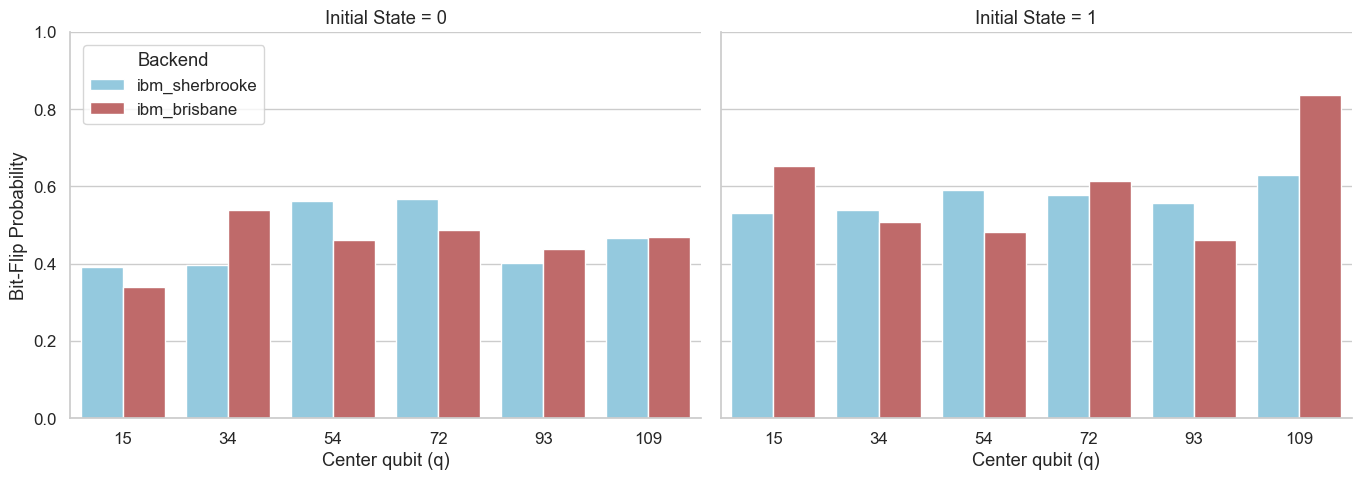

In [118]:
# # ---------------------------------------------------------------------
# # 2) Build the bar chart
# #    - Facet by INIT_STATE (one subplot per initial state)
# #    - Colour bars by backend
# #    - X-axis: centre qubit index (center_q)
# #    - Y-axis: p_flip_manual
# # ---------------------------------------------------------------------
# sns.set_theme(style="whitegrid", font_scale=1.1)

# palette = {'ibm_sherbrooke': 'skyblue', 'ibm_brisbane': 'indianred'}  # light green and light red


# g = sns.catplot(
#     data=df,
#     x="center_q",
#     y="p_flip_manual",
#     hue="backend",
#     palette=palette,
#     col="INIT_STATE",          # split into sub-graphs
#     kind="bar",
#     height=5,
#     aspect=1.2,
#     dodge=True                 # separate backend bars side-by-side
# )

# # Tidy up axis labels and titles
# # Set y-axis to go from 0 to 1 for all subplots
# for ax in g.axes.flat:
#     ax.set_ylim(0, 1)
# g.set_axis_labels("Center qubit (q)", "Bit-Flip Probability")
# g.set_titles("Initial State = {col_name}")
# g.figure.tight_layout()
# g._legend.remove()
# # Use plt.legend() to place it manually
# plt.legend(
#     title="Backend",
#     loc="lower right",
#     bbox_to_anchor=(-0.71, 0.74)
# )
# plt.show()
